> **Note on the HYDRUS-1D reference simulation — known limitation**
>
> HYDRUS-1D is used here as a vertical-1-D variably-saturated reference. Its modified-Picard mixed-form Richards solver is known to lose convergence in the persistently-saturated, surface-ponded regime: when the soil column reaches hydrostatic equilibrium with the water table at the surface, the head gradient that drives the iteration collapses and the run can terminate before the requested simulation horizon. The `phydrus` driver returns a clean exit code in this case, so the failure is silent unless explicitly checked. This case does not reach that regime within the simulated horizon, so the HYDRUS reference covers the full window; the issue is documented here for cross-reference with the intensive-sand and intensive-sand-over-loam companion notebooks where it does manifest.
>
> See the manuscript section "Limits of the HYDRUS-1D reference and of synthetic-case verification" for the full discussion and supporting citations.

# GWSWEX vs HYDRUS-1D - intensive / clay

32-day, 4-phase column experiment with hourly macro-steps and
explicit ponding resolution (HYDRUS-1D top BC = atmospheric-with-surface-layer,
GWSWEX SW reservoir). All values below come from `experiment_definitions.json`.

| Parameter | Value |
|-----------|-------|
| Column | 1.5 m, 150 layers @ 1.0 cm |
| Soil profile (top→bottom) | clay (100%) |
| Initial WT depth | 120 cm below surface |
| Warmup (72 h) | zero forcing |
| Wet (240 h) | P = 0.042, PE = 0.010, PT = 0.005 cm h⁻¹ |
| Dry (288 h) | P = 0, PE = 0.48, PT = 0.36 cm d⁻¹ |
| Cooldown (168 h) | zero forcing |
| Root depth (constant) | 0.6 m |

Solver- and material-specific tuned parameters (`MODEL_PARAMS`, `ET_STRESS`,
`solver kwargs`) are taken from the `oat_tuned` section of the same JSON file.
Outputs land under `outputs/intensive/clay/`.


In [ ]:
from __future__ import annotations
from datetime import datetime, timedelta
from pathlib import Path
import sys

import numpy as np
from gwswex import GWSWEXmodel

# All pre/post-processing, HYDRUS-1D drive, plotting and metrics live in the
# shared helper module so the cells below stay focused on GWSWEX itself.
sys.path.insert(0, str(Path('.').resolve()))
import _compare_helpers as ch

ch.setup_plot_style()

SETUP, SOIL_TAG = 'intensive', 'clay'
SPEC = ch.load_experiment(SETUP, SOIL_TAG)
print(
    f'Loaded SoT: setup={SPEC.setup}, soil={SPEC.soil_tag}, '
    f'T_TOTAL={SPEC.T_TOTAL_d} d, NL={SPEC.NL}, '
    f'tuned solvers: {list(SPEC.tuned)}'
)

Loaded SoT: setup=intensive, soil=clay, T_TOTAL=32 d, NL=150, tuned solvers: ['implicit', 'explicit']


In [ ]:
# ── HYDRUS-1D reference run (drive + parse via the helper) ───────────────────
# Top BC: basic = top_bc=3 (surface runoff); intensive = top_bc=2 (ponding).
HYD = ch.run_hydrus(SPEC)
print(
    f'HYDRUS-1D done in {HYD.wall_s:.2f} s, '
    f'WT range {HYD.gw_depth_cm.min():.1f}-{HYD.gw_depth_cm.max():.1f} cm, '
    f'cum AE={HYD.cum_ae_cm[-1]:.2f} cm, cum AT={HYD.cum_at_cm[-1]:.2f} cm, '
    f'final MB err={HYD.mb_err_cm[-1]:+.4f} cm'
)

INFO: Successfully wrote /Users/veethahavya/Desktop/gwswex/examples/gwswex-vs-hydrus1d/outputs/intensive/clay/phydrus/hydrus1d/SELECTOR.IN


INFO: Successfully wrote /Users/veethahavya/Desktop/gwswex/examples/gwswex-vs-hydrus1d/outputs/intensive/clay/phydrus/hydrus1d/PROFILE.DAT


INFO: Successfully wrote /Users/veethahavya/Desktop/gwswex/examples/gwswex-vs-hydrus1d/outputs/intensive/clay/phydrus/hydrus1d/ATMOSPH.IN


INFO: Hydrus-1D Simulation Successful.


HYDRUS-1D done in 0.30 s, WT range 0.0-135.5 cm, cum AE=9.65 cm, cum AT=5.59 cm, final MB err=+0.0003 cm


In [ ]:
# ── GWSWEX setup helper (intensive setup: T='h', constant root depth) ────────
def build_gwswex_intensive(solver: str) -> GWSWEXmodel:
    """Build a fully-configured GWSWEXmodel for the intensive-setup column.

    Hourly macro-steps; soil K_sat is converted from m d^-1 to m h^-1 so units
    match the GWSWEX time base. Tuned params come from oat_tuned in the SoT.
    """
    cfg = SPEC.tuned[solver]
    out = SPEC.outputs_root / f'compare-{solver}.nc'
    out.parent.mkdir(parents=True, exist_ok=True)

    bot = [list(np.round(np.linspace(SPEC.Z_TOP - SPEC.DZ, SPEC.Z_BOT, SPEC.NL), 10))]
    m = GWSWEXmodel(name=f'compare-{solver}', T='h', L='m', output_fpath=str(out))
    m.init_space(ne=1, nl=SPEC.NL, top=[[SPEC.Z_TOP]], bot=bot, sID=[SPEC.layer_mat_ids], vID=[[1]])
    for mat in SPEC.materials:
        mh = dict(mat)
        mh['K_sat'] = mat['K_sat'] / 24.0  # m d^-1 -> m h^-1
        m.add_material(**mh)
    m.add_vegetation(
        id=1,
        name='pasture',
        root_depth_initial=SPEC.root_d_initial,
        root_depth_final=SPEC.root_d_final,
        root_growth_model=SPEC.root_growth_model,
        et_stress=cfg['et_stress'],
    )
    m.init_time(n_steps=SPEC.n_steps, dt=1.0, dt_min=1 / 60)
    m.set_initial_conditions(gw=[SPEC.Z_WT], sw=[0.0], uz=[-999])
    m.set_solver(solver=solver, **cfg['solver_params'])
    m.set_model_params(**cfg['model_params'])
    m.set_forcing(precip=0.0, pet=0.0, ptt=0.0)  # placeholder; updated per-step
    m.init()
    return m

In [ ]:
print('Running GWSWEX implicit ...')
RES_I = ch.collect_intensive(SPEC, build_gwswex_intensive('implicit'))
RES_I.label = 'GWSWEX implicit'
print(
    f'  wall {RES_I.wall_s:.2f} s, '
    f'WT @ end = {RES_I.gw_depth_cm[-1]:.1f} cm, '
    f'max SW = {RES_I.sw_cm.max():.2f} cm'
)

Running GWSWEX implicit ...


  wall 2.87 s, WT @ end = 101.1 cm, max SW = 4.12 cm


In [ ]:
print('Running GWSWEX explicit ...')
RES_E = ch.collect_intensive(SPEC, build_gwswex_intensive('explicit'))
RES_E.label = 'GWSWEX explicit'
print(
    f'  wall {RES_E.wall_s:.2f} s, '
    f'WT @ end = {RES_E.gw_depth_cm[-1]:.1f} cm, '
    f'max SW = {RES_E.sw_cm.max():.2f} cm'
)

Running GWSWEX explicit ...


  wall 3.16 s, WT @ end = 145.4 cm, max SW = 3.52 cm


In [ ]:
RUNS = {'GWSWEX implicit': RES_I, 'GWSWEX explicit': RES_E}

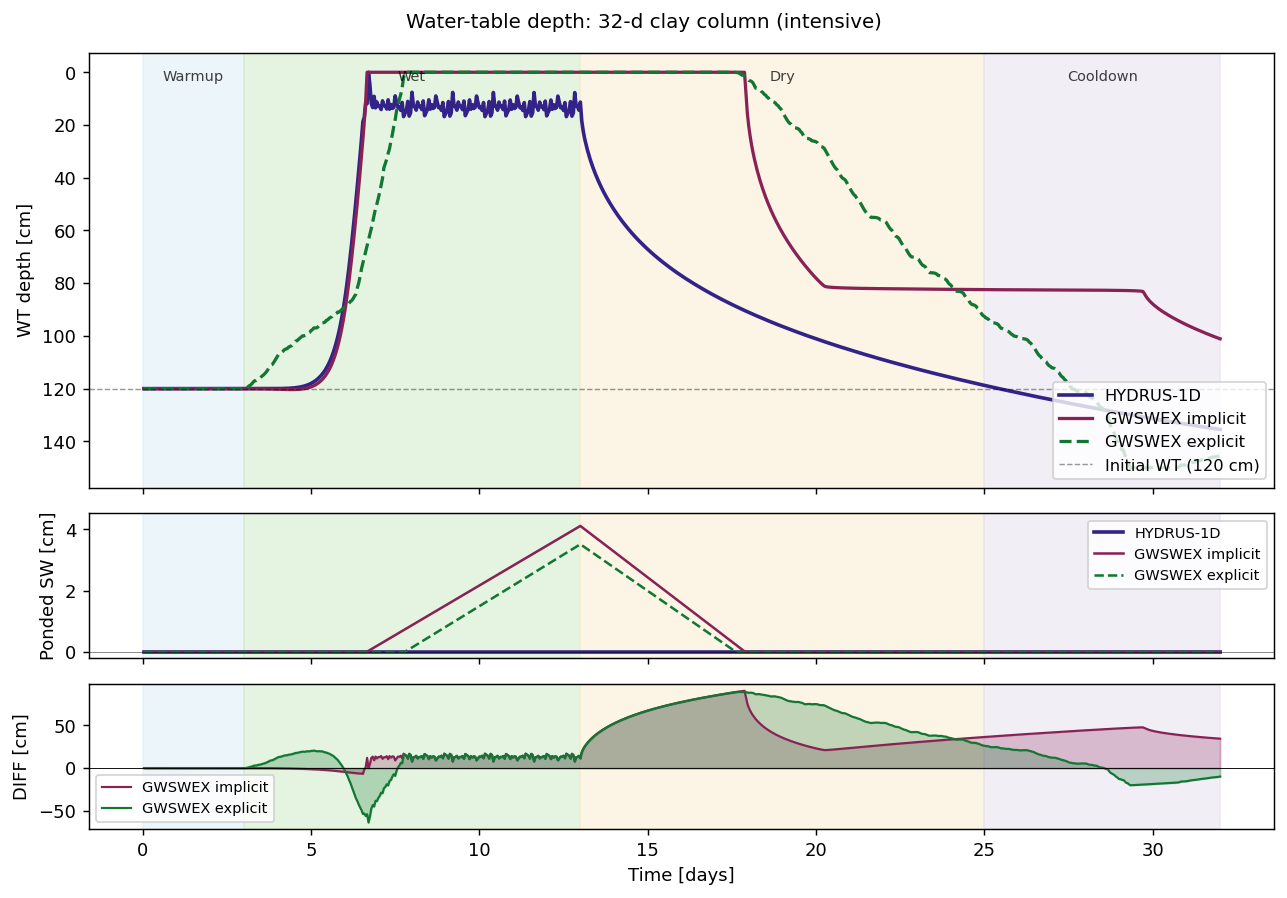

GWSWEX implicit: RMSE=37.59 cm, MAE=29.29 cm, NSE=0.252, Bias=-28.87 cm
GWSWEX explicit: RMSE=41.65 cm, MAE=31.17 cm, NSE=0.081, Bias=-24.98 cm


In [ ]:
ch.plot_water_table(SPEC, HYD, RUNS)

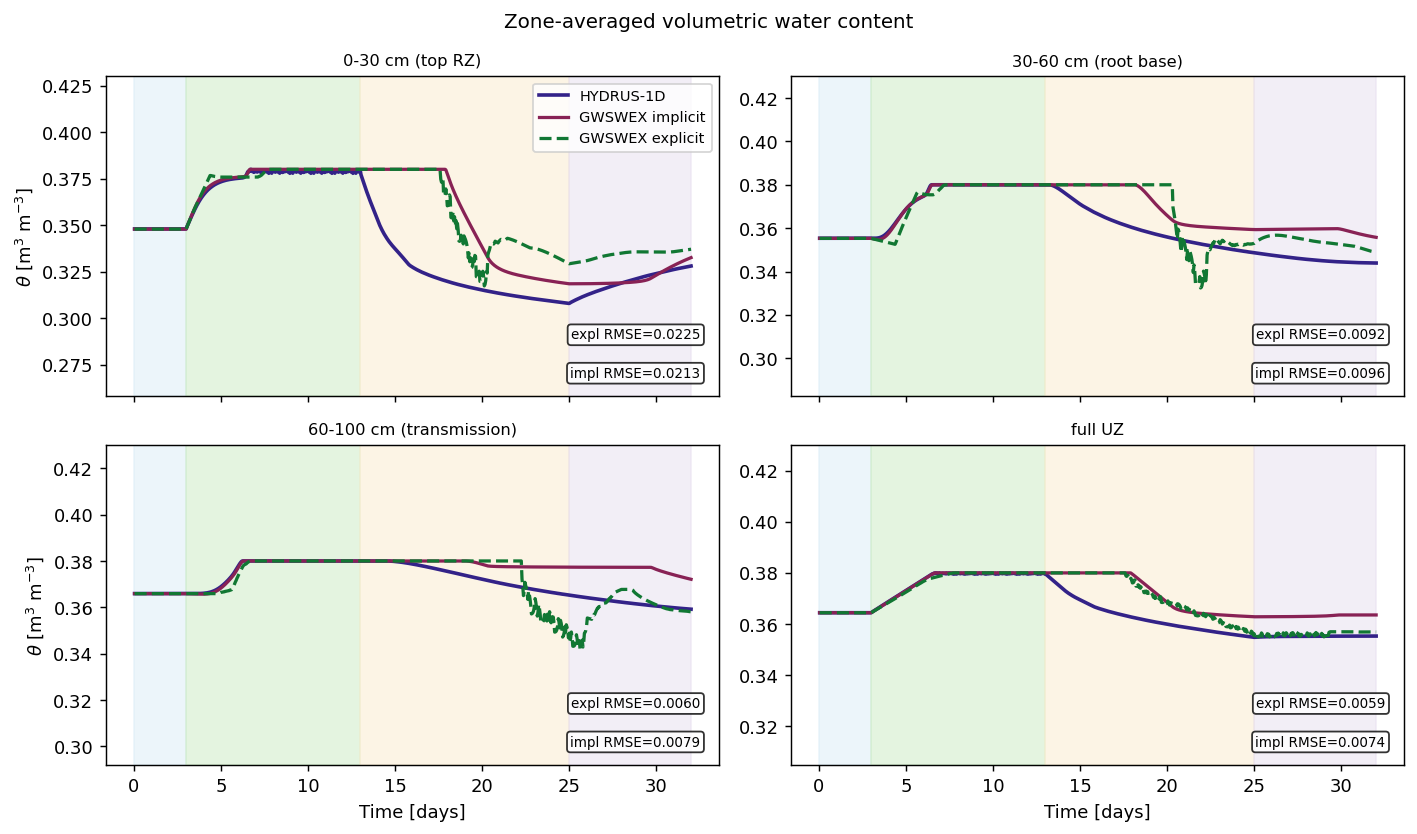

In [ ]:
ch.plot_zone_theta(
    SPEC,
    HYD,
    RUNS,
    zones=[
        (0, 30, '0-30 cm (top RZ)'),
        (30, 60, '30-60 cm (root base)'),
        (60, 100, '60-100 cm (transmission)'),
        (0, int((SPEC.Z_TOP - SPEC.Z_BOT) * 100), 'full UZ'),
    ],
)

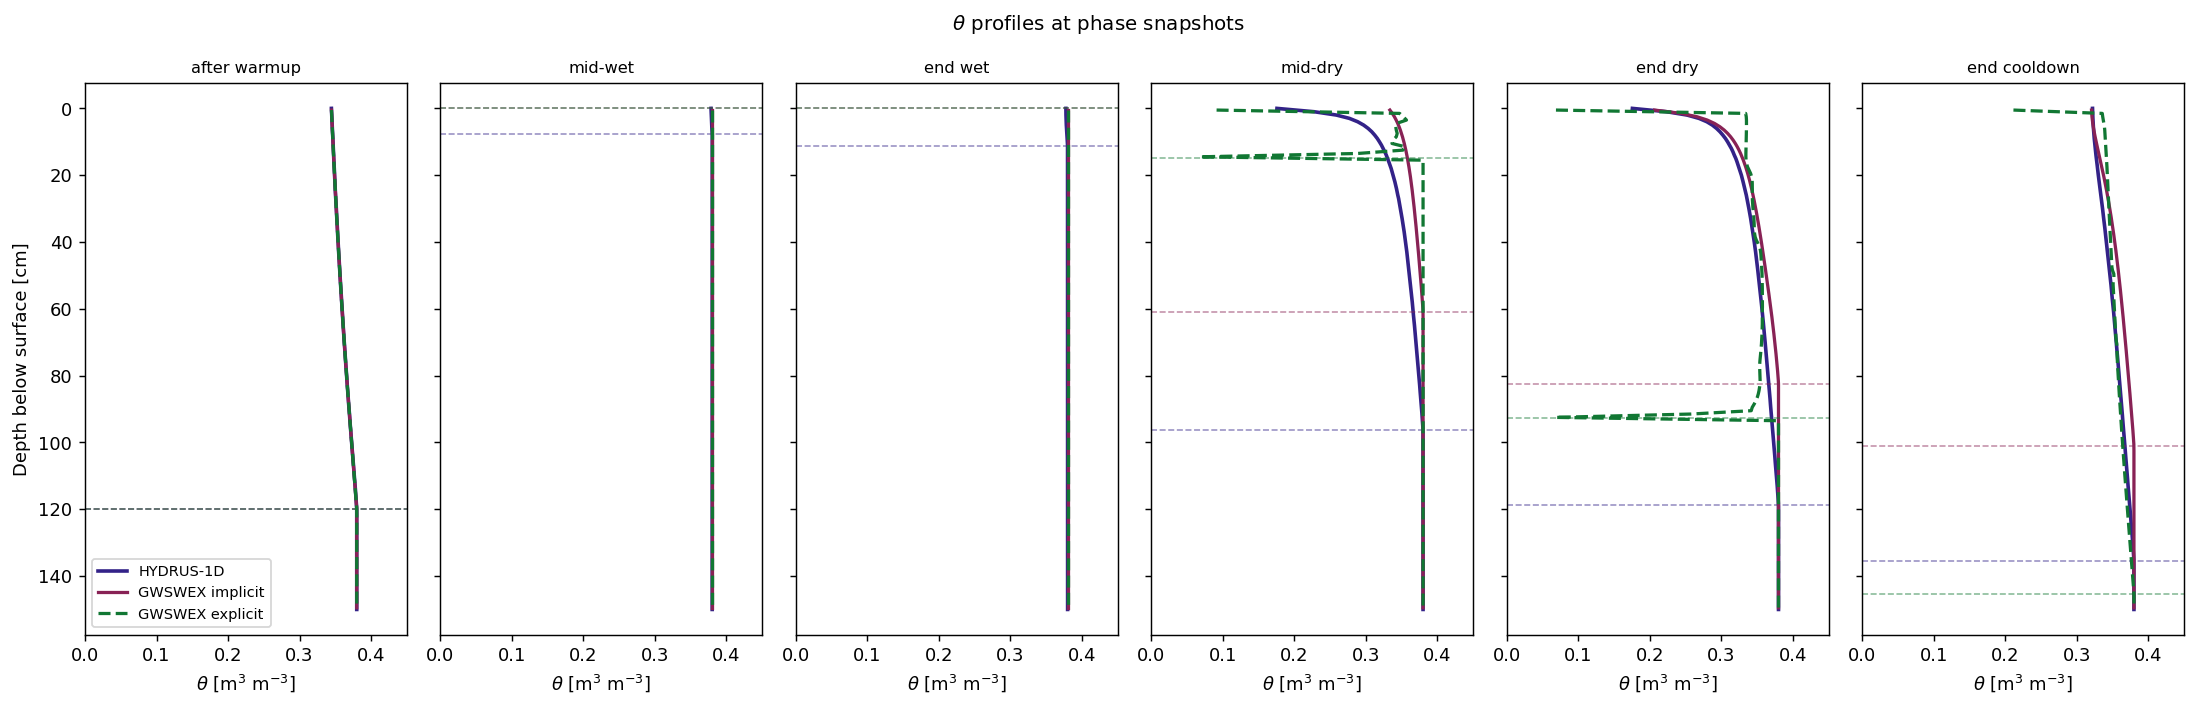

In [ ]:
ch.plot_theta_snapshots(
    SPEC,
    HYD,
    RUNS,
    snaps=[
        (SPEC.summary['T_WU_h'] - 1, 'after warmup'),
        (SPEC.summary['T_WU_h'] + SPEC.summary['T_WET_h'] // 2 - 1, 'mid-wet'),
        (SPEC.summary['T_WU_h'] + SPEC.summary['T_WET_h'] - 1, 'end wet'),
        (SPEC.summary['T_WU_h'] + SPEC.summary['T_WET_h'] + SPEC.summary['T_DRY_h'] // 2 - 1, 'mid-dry'),
        (SPEC.summary['T_WU_h'] + SPEC.summary['T_WET_h'] + SPEC.summary['T_DRY_h'] - 1, 'end dry'),
        (SPEC.n_steps - 1, 'end cooldown'),
    ],
)

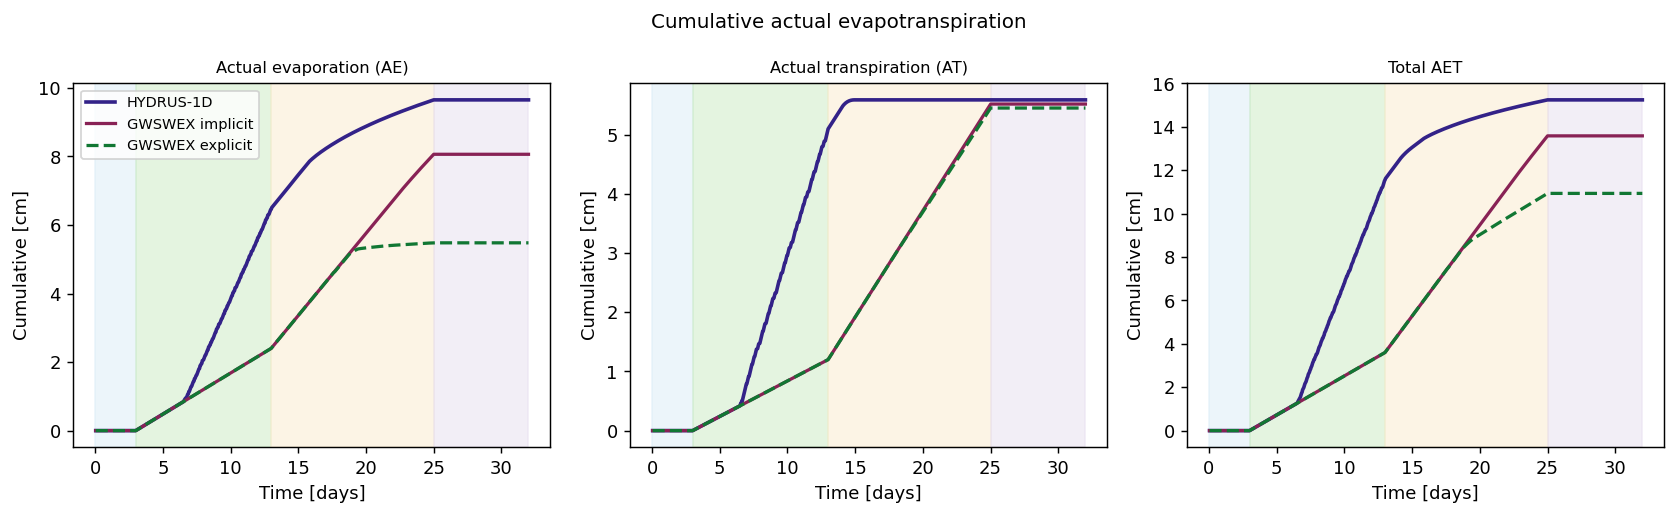

                             HYDRUS-1D  GWSWEX implicit  GWSWEX explicit
           Cum AE [cm]           9.652           8.064           5.480
           Cum AT [cm]           5.590           5.519           5.452
          Cum AET [cm]          15.241          13.582          10.931


In [ ]:
ch.plot_cum_et(SPEC, HYD, RUNS)

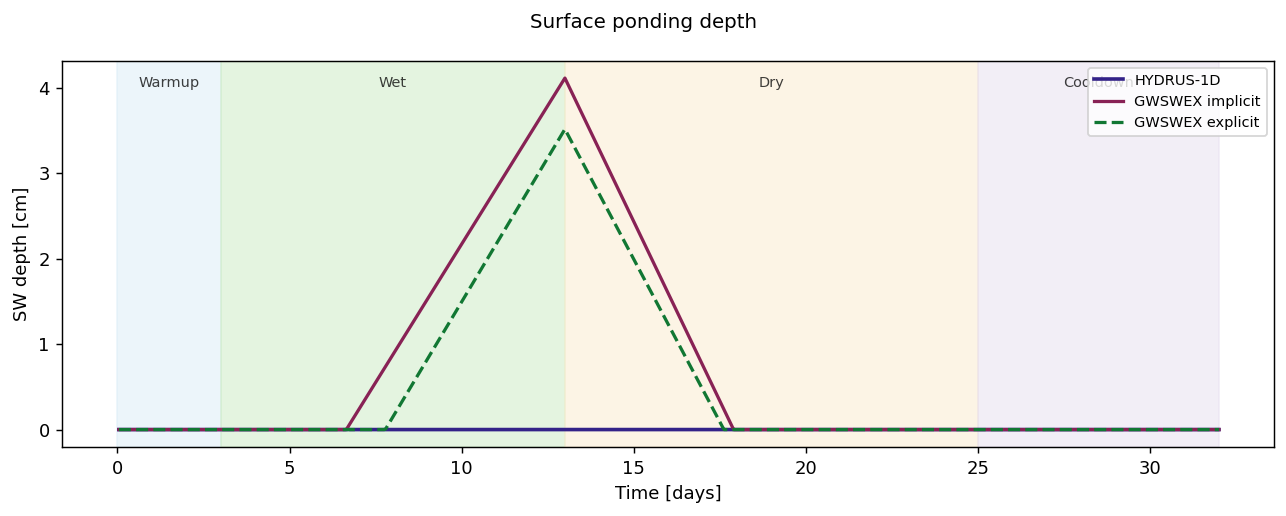

Model                  Max SW [cm]    End SW [cm]
--------------------------------------------------
HYDRUS-1D                     0.00           0.00
GWSWEX implicit               4.12           0.00
GWSWEX explicit               3.52           0.00


In [ ]:
ch.plot_surface_ponding(SPEC, HYD, RUNS)

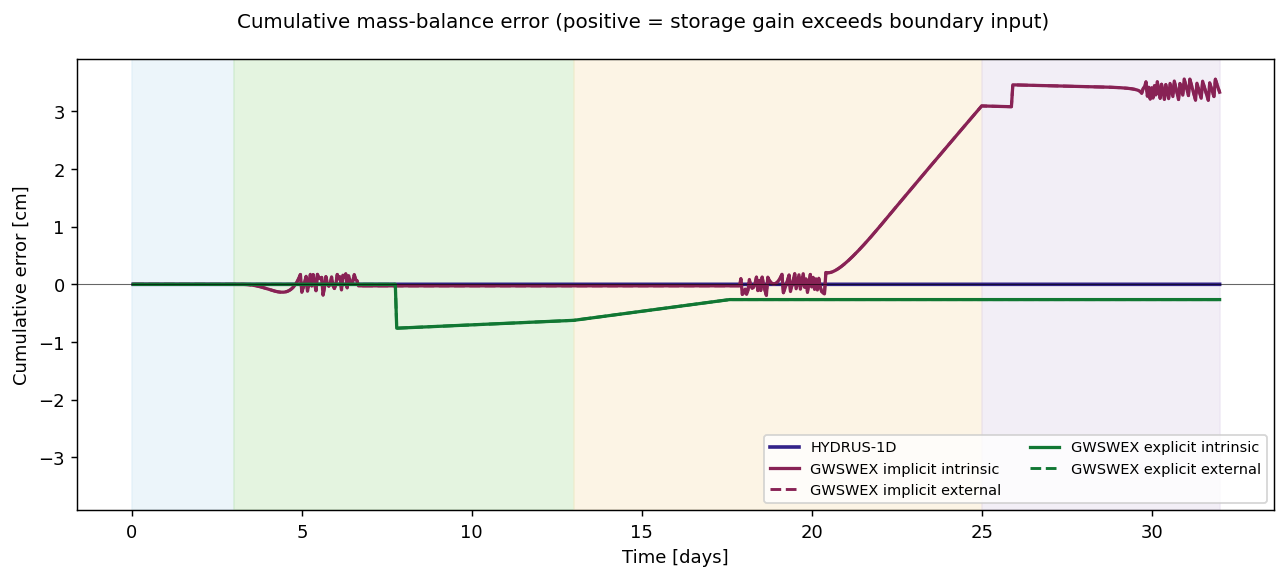


Cumulative MB error at t = 32 d
Model                        Final [cm]    Max |err| [cm]
------------------------------------------------------------
HYDRUS-1D                     +0.000300          0.000602
GWSWEX implicit intrinsic      +3.329904          3.558592
GWSWEX implicit external      +3.329904          3.558592
GWSWEX explicit intrinsic      -0.264725          0.760559
GWSWEX explicit external      -0.264725          0.760559


In [ ]:
ch.plot_mass_balance(SPEC, HYD, RUNS)

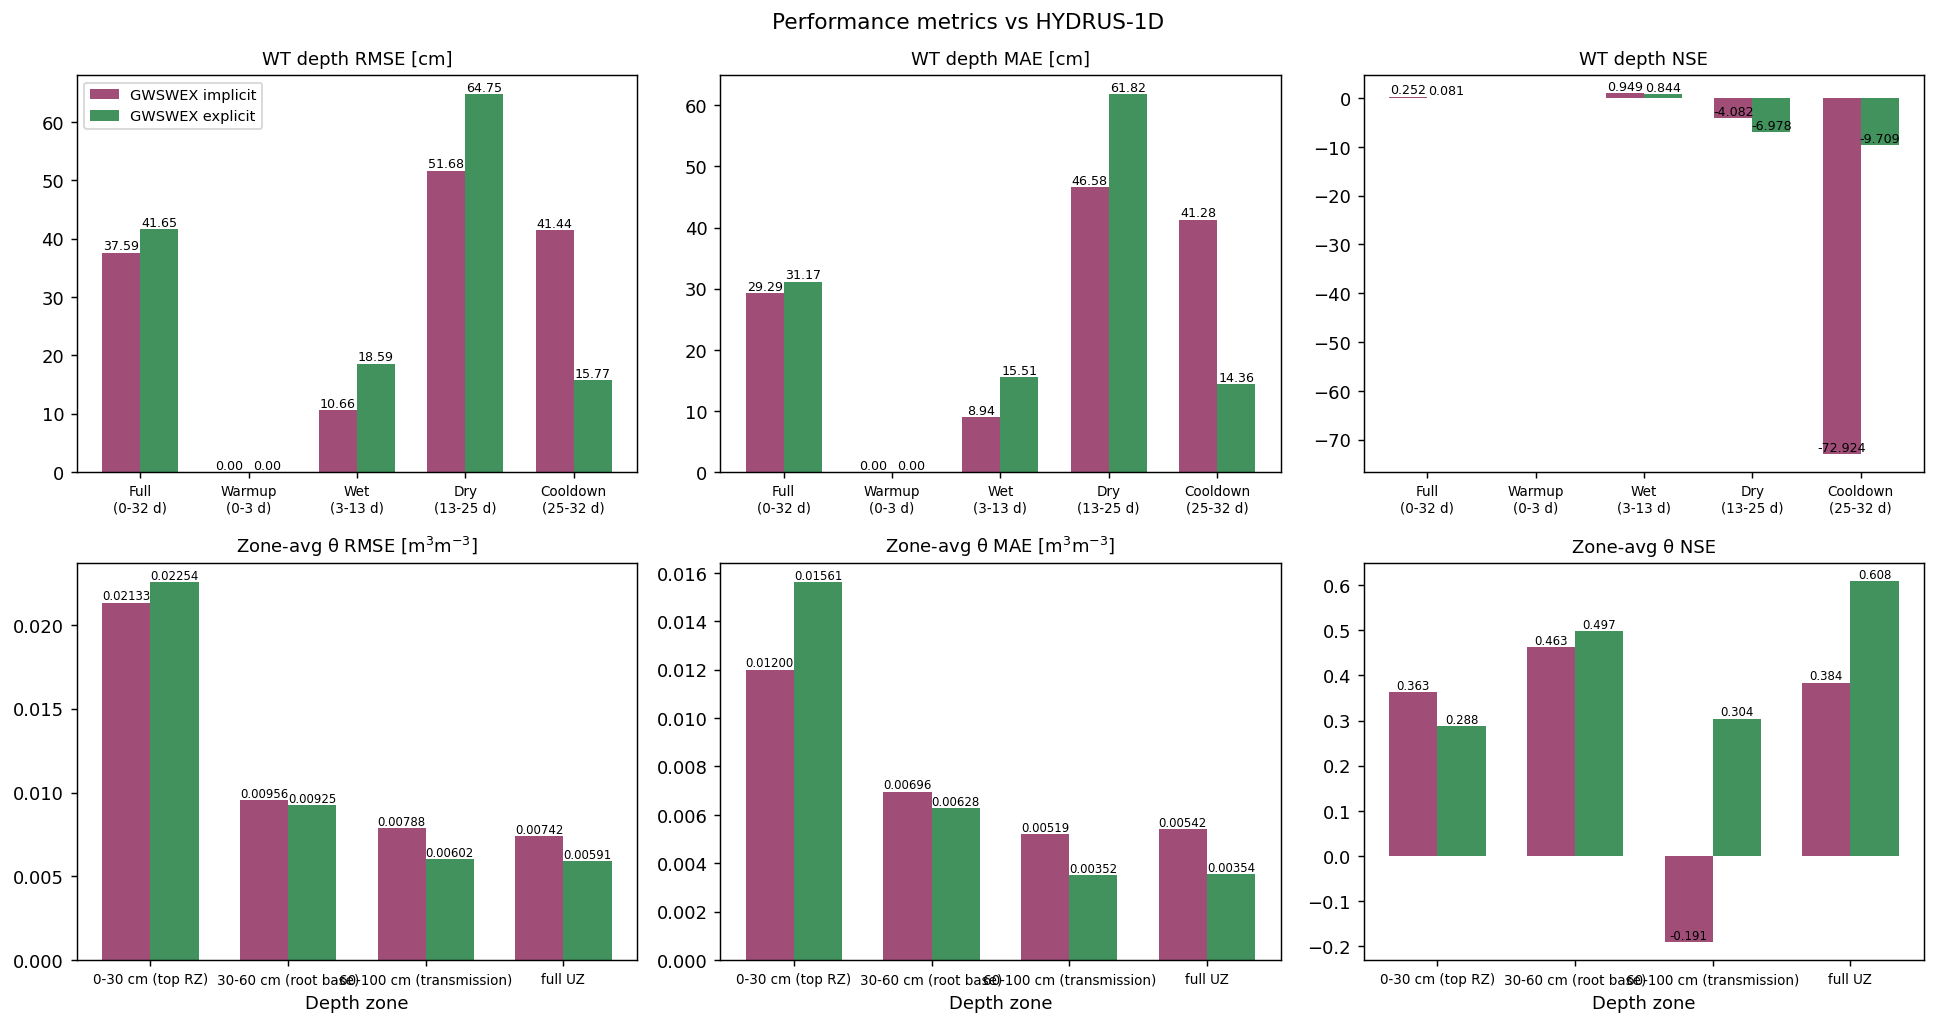

In [ ]:
ch.plot_metrics_summary(
    SPEC,
    HYD,
    RUNS,
    zone_specs=[
        (0, 30, '0-30 cm (top RZ)'),
        (30, 60, '30-60 cm (root base)'),
        (60, 100, '60-100 cm (transmission)'),
        (0, int((SPEC.Z_TOP - SPEC.Z_BOT) * 100), 'full UZ'),
    ],
)